# Homework 1: Unsupervised Learning with AutoEncoders
This notebook contains the complete implementation for training a standard Linear Autoencoder on the MNIST dataset, followed by K-Means clustering in the latent space and performance evaluation.

**Team Information:**
- Team Leader: 
- Team Members: 

## 1. Setup & Installations
Below we install necessary libraries (if they are not already installed on Colab) and import them.

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.optimize import linear_sum_assignment

## 2. Dataset Loading
Downloading and preparing the MNIST testing and training data.

In [6]:
def get_dataloaders(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

train_loader, test_loader = get_dataloaders(batch_size=128)
print("Data Loaders Initialized.")

Data Loaders Initialized.


## 3. Define the Autoencoder Architecture
Standard Linear AutoEncoder with a 32-dimensional latent space.

In [7]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim

        # Yeni ve Daha Derin Encoder (3 Bloklu)
        self.encoder_conv = nn.Sequential(
            # Blok 1: 28x28 -> 14x14
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2),
            
            # Blok 2: 14x14 -> 7x7
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2),
            
            # Blok 3: 7x7 -> 4x4 (Stride 2 kullanarak boyutu düşürüyoruz)
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
        )
        
        # Yeni Flatten Boyutu: 128 * 4 * 4 = 2048
        self.encoder_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, latent_dim),
        )

        # Yeni Decoder
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 128 * 4 * 4),
            nn.ReLU(True),
        )
        
        self.decoder_conv = nn.Sequential(
            # 4x4 -> 8x8 (output_padding=1 ile 7x7'ye değil 8x8'e zorlayabilirdik ama 
            # MNIST için 4->7->14->28 akışı daha sağlıklıdır)
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0), # -> 64 x 7 x 7
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            # 7x7 -> 14x14
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), # -> 32 x 14 x 14
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            
            # 14x14 -> 28x28
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> 1 x 28 x 28
            nn.Sigmoid(),
        )

    # ESKİ FONKSİYON İSİMLERİNİ KORUDUK:
    def forward(self, x):
        encoded = self.encode(x)
        decoded = self.decode(encoded)
        return decoded, encoded # Eski kodun beklediği çift dönüş

    def encode(self, x):
        x = self.encoder_conv(x)
        x = self.encoder_fc(x)
        return x

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(-1, 128, 4, 4) # Yeni mimariye göre kanal sayısı 128
        x = self.decoder_conv(x)
        return x

## 4. Train Autoencoder
Train using Colab GPU for 30 epochs and plot the MSE loss curve.

Using device: mps

Training Autoencoder with latent_dim = 2 (15 Epochs)
  Epoch [ 1/15]  Train Loss: 0.0572  |  Test Loss: 0.0463
  Epoch [ 2/15]  Train Loss: 0.0441  |  Test Loss: 0.0432
  Epoch [ 3/15]  Train Loss: 0.0422  |  Test Loss: 0.0418
  Epoch [ 4/15]  Train Loss: 0.0409  |  Test Loss: 0.0409
  Epoch [ 5/15]  Train Loss: 0.0402  |  Test Loss: 0.0402
  Epoch [ 6/15]  Train Loss: 0.0397  |  Test Loss: 0.0398
  Epoch [ 7/15]  Train Loss: 0.0392  |  Test Loss: 0.0393
  Epoch [ 8/15]  Train Loss: 0.0389  |  Test Loss: 0.0391
  Epoch [ 9/15]  Train Loss: 0.0385  |  Test Loss: 0.0387
  Epoch [10/15]  Train Loss: 0.0383  |  Test Loss: 0.0387
  Epoch [11/15]  Train Loss: 0.0380  |  Test Loss: 0.0384
  Epoch [12/15]  Train Loss: 0.0378  |  Test Loss: 0.0382
  Epoch [13/15]  Train Loss: 0.0376  |  Test Loss: 0.0385
  Epoch [14/15]  Train Loss: 0.0374  |  Test Loss: 0.0383
  Epoch [15/15]  Train Loss: 0.0372  |  Test Loss: 0.0382

  ✓ Final Train Loss: 0.0372  |  Final Test Loss: 0.0382


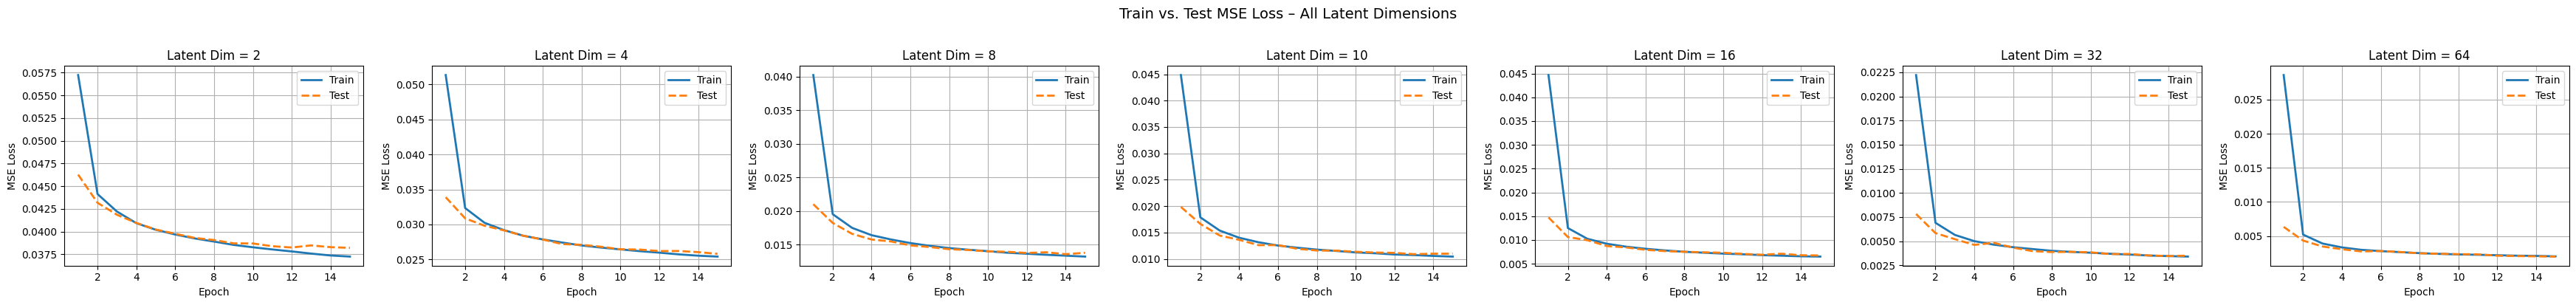

In [8]:
def train_autoencoder(model, train_loader, test_loader, epochs=15, lr=1e-3, device='cpu'):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_loss_history = []
    test_loss_history = []
    
    for epoch in range(epochs):
        # ── Training ──────────────────────────────────────────────
        model.train()
        epoch_train_loss = 0
        for batch_features, _ in train_loader:
            batch_features = batch_features.to(device)
            optimizer.zero_grad()
            outputs, _ = model(batch_features)
            loss = criterion(outputs, batch_features)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
        avg_train_loss = epoch_train_loss / len(train_loader)
        train_loss_history.append(avg_train_loss)

        # ── Evaluation (no gradients) ─────────────────────────────
        model.eval()
        epoch_test_loss = 0
        with torch.no_grad():
            for batch_features, _ in test_loader:
                batch_features = batch_features.to(device)
                outputs, _ = model(batch_features)
                loss = criterion(outputs, batch_features)
                epoch_test_loss += loss.item()
        avg_test_loss = epoch_test_loss / len(test_loader)
        test_loss_history.append(avg_test_loss)

        print(f"  Epoch [{epoch+1:2d}/{epochs}]  Train Loss: {avg_train_loss:.4f}  |  Test Loss: {avg_test_loss:.4f}")

    return train_loss_history, test_loss_history

# Set device
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

latent_dims = [2, 4, 8, 10, 16, 32, 64]
all_train_losses = {}
all_test_losses = {}
trained_models = {}

fig, axes = plt.subplots(1, len(latent_dims), figsize=(5 * len(latent_dims), 4), sharey=False)

for ax, dim in zip(axes, latent_dims):
    print(f"\n{'='*40}")
    print(f"Training Autoencoder with latent_dim = {dim} (15 Epochs)")
    print(f"{'='*40}")

    model = Autoencoder(latent_dim=dim).to(device)

    train_losses, test_losses = train_autoencoder(
        model, train_loader, test_loader, epochs=15, device=device
    )
    print(f"\n  ✓ Final Train Loss: {train_losses[-1]:.4f}  |  Final Test Loss: {test_losses[-1]:.4f}")

    all_train_losses[dim] = train_losses
    all_test_losses[dim]  = test_losses
    trained_models[dim]   = model

    epochs_range = range(1, len(train_losses) + 1)
    ax.plot(epochs_range, train_losses, label='Train', linewidth=2)
    ax.plot(epochs_range, test_losses,  label='Test',  linewidth=2, linestyle='--')
    ax.set_title(f'Latent Dim = {dim}', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True)

fig.suptitle('Train vs. Test MSE Loss – All Latent Dimensions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('output_loss_curve.png', bbox_inches='tight', dpi=150)
plt.show()


## 5. Produce Reconstructions
Visualizing original inputs vs. outputs generated from the 32D latent space.

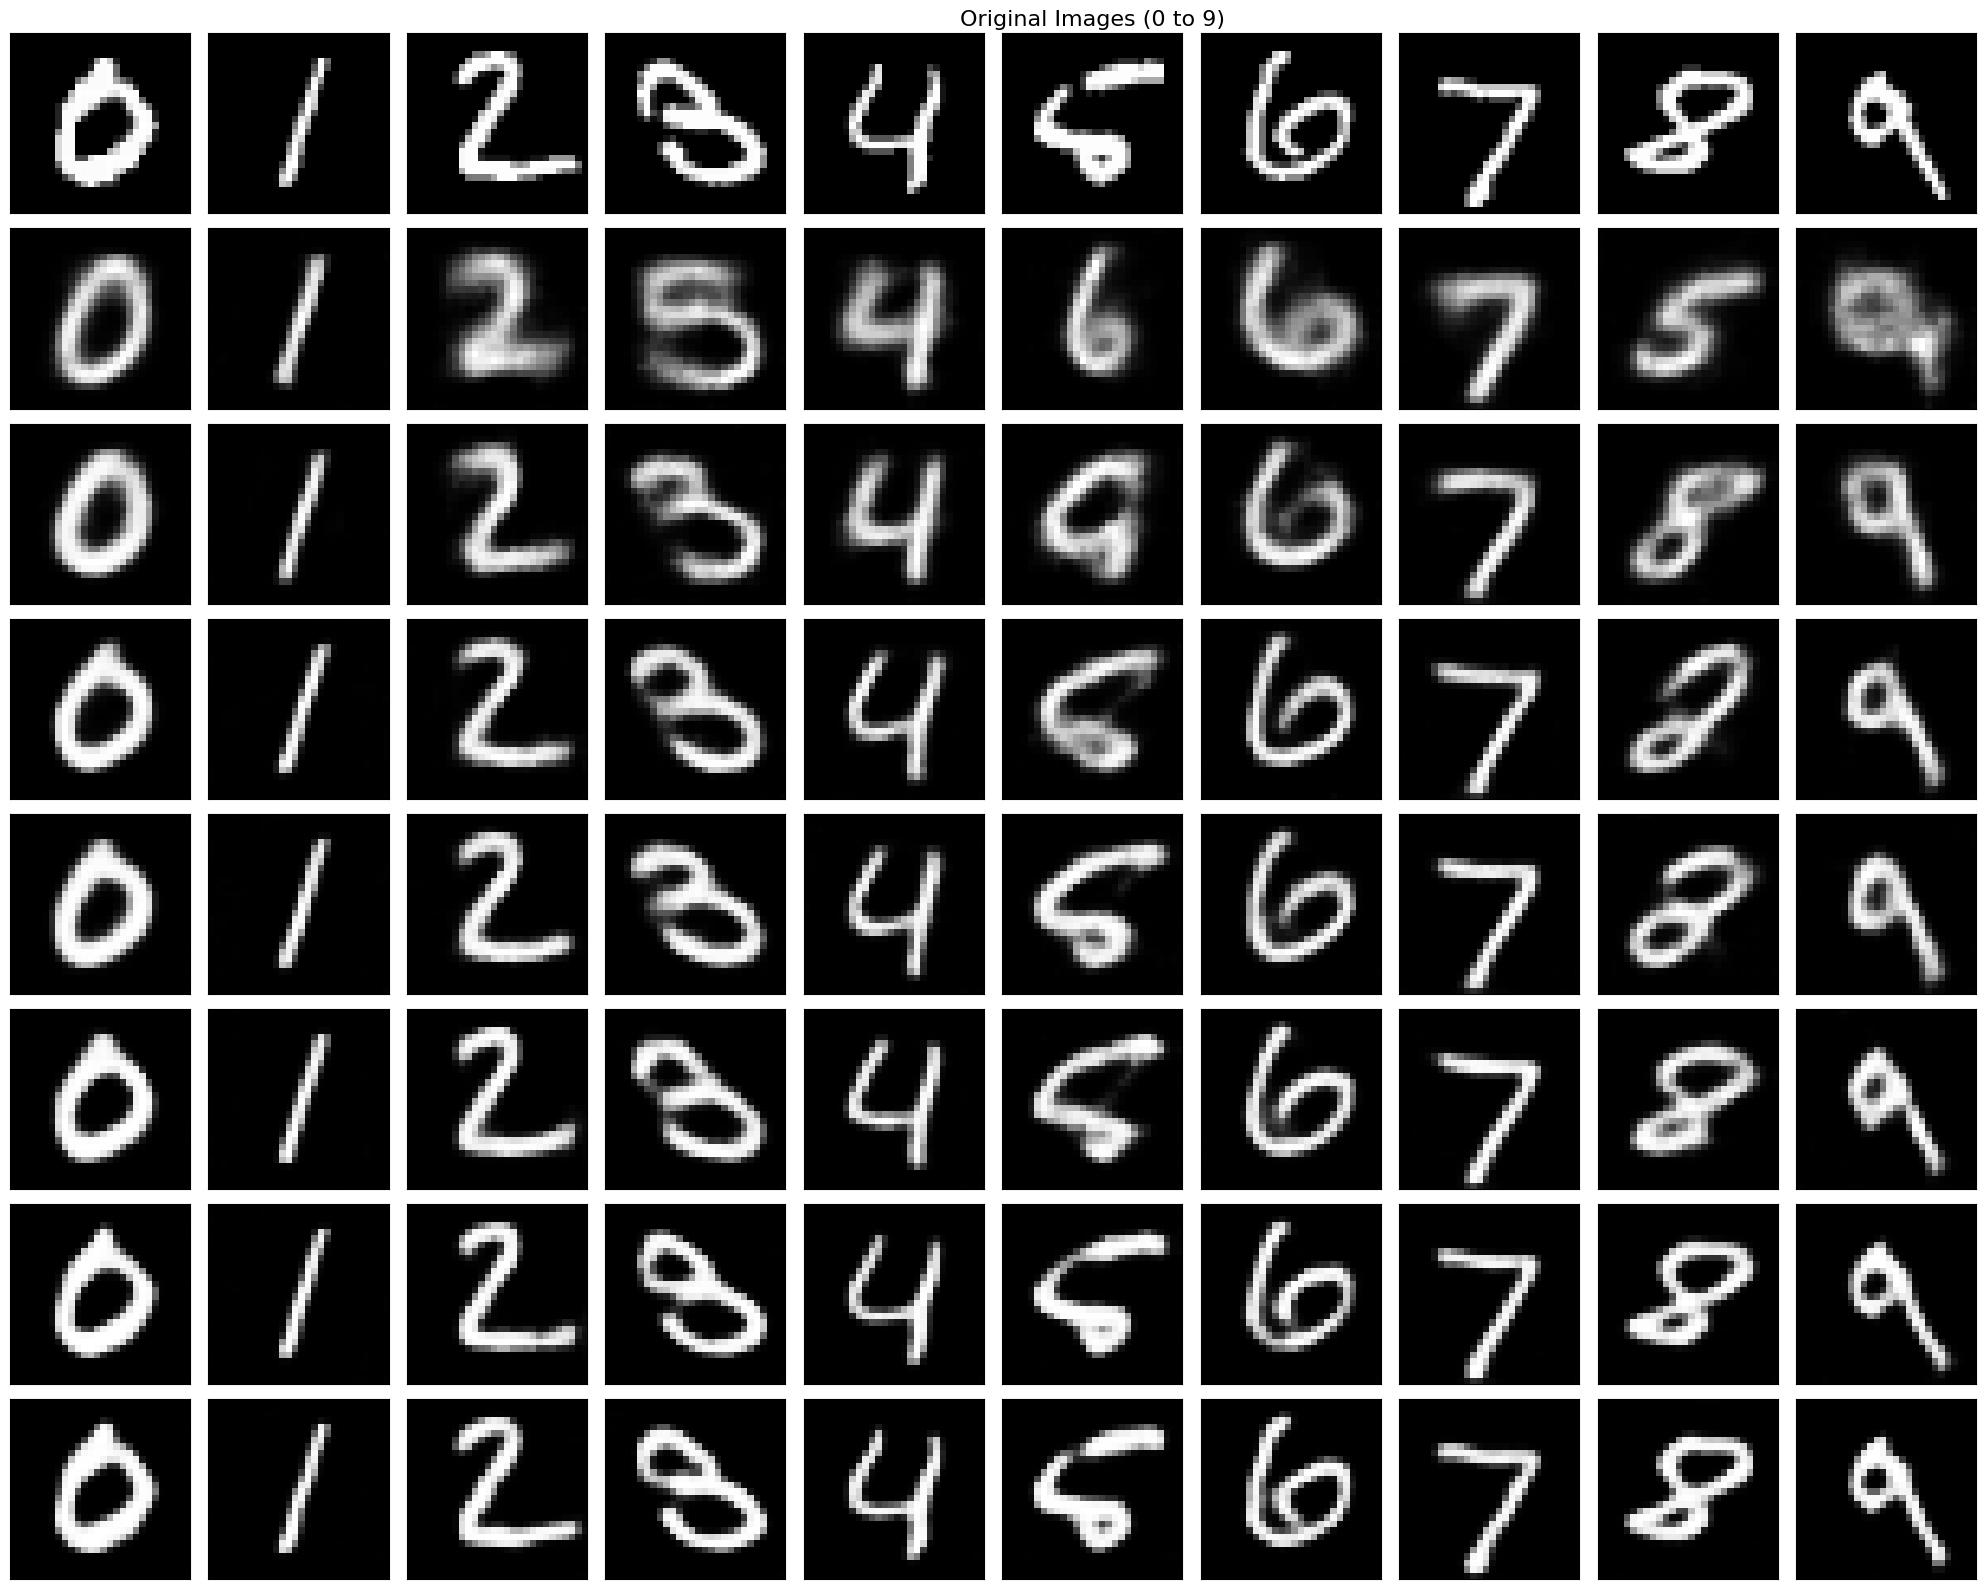


Latent space değişkenleri (latent_reps, labels vb.) en iyi model olan 10 boyutluya göre atandı.


In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def get_latent_representations_and_images(model, test_loader, device='cpu', num_images=10):
    model.eval()
    latent_reps = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            _, encoded = model(images)
            
            latent_reps.append(encoded.cpu().numpy())
            all_labels.append(labels.numpy())
                
    latent_reps = np.concatenate(latent_reps, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    
    return latent_reps, all_labels

# 1. Bütün test setini ağdan geçirip latent vector'leri alalım (Tüm modeller için)
latent_data_per_dim = {}
for dim in latent_dims:
    reps, lbls = get_latent_representations_and_images(trained_models[dim], test_loader, device=device)
    latent_data_per_dim[dim] = reps
# labels hepsi için aynı zaten, o yüzden 1 tanesini tutmak yeterli
labels = lbls 

# 2. Orjinal Test Setinden 0'dan 9'a kadar Hepsinden Tam 1 Adet Bulalım
target_digits = list(range(10))
found_digits = {}
original_target_images = []
target_indices = []

# Datasetin içinde dönüp sırayla 0,1,2..9 bulalım
for idx, (img, label) in enumerate(test_loader.dataset):
    l = label.item() if isinstance(label, torch.Tensor) else label
    if l in target_digits and l not in found_digits:
        found_digits[l] = True
        original_target_images.append(img.numpy())
        target_indices.append(idx)
    if len(found_digits) == 10:
        break

# Resimleri 0'dan 9'a sıralayalım
sorted_pairs = sorted(zip(found_digits.keys(), original_target_images, target_indices), key=lambda x: x[0])
original_target_images = [pair[1] for pair in sorted_pairs]
target_indices = [pair[2] for pair in sorted_pairs]

num_images = 10
fig, axes = plt.subplots(len(latent_dims) + 1, num_images, figsize=(20, 2 * (len(latent_dims) + 1)))

# İlk Satır: Orijinal Görüntüler (0'dan 9'a sıralı)
for i in range(num_images):
    ax = axes[0, i]
    ax.imshow(original_target_images[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == 5: 
        ax.set_title("Original Images (0 to 9)", fontsize=16)

# Diğer Satırlar: Her bir latent_dim için rekonstrüksiyonlar
for row_idx, dim in enumerate(latent_dims):
    current_model = trained_models[dim]
    current_model.eval()
    
    # Sadece seçtiğimiz 10 resmin tensor halini oluşturup modelden geçirelim
    imgs_tensor = torch.tensor(np.array(original_target_images)).to(device)
    
    with torch.no_grad():
        reconstructed_imgs_tensor, _ = current_model(imgs_tensor)
        
    recon_imgs = reconstructed_imgs_tensor.cpu().numpy()
    
    for i in range(num_images):
        ax = axes[row_idx + 1, i]
        ax.imshow(recon_imgs[i].squeeze(), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        
        # Satır isimleri
        if i == 0:
            ax.set_ylabel(f"Latent Dim: {dim}", visible=True, rotation=0, labelpad=50, fontsize=12, va='center')

plt.tight_layout()
plt.show()

# ==============================================================================
# K-Means vb. diğer çizim işlemlerinde en iyi performans veren 10 boyut kabul edilsin:
latent_reps = latent_data_per_dim[10]
print("\nLatent space değişkenleri (latent_reps, labels vb.) en iyi model olan 10 boyutluya göre atandı.")
# ==============================================================================

## 6. Plotting Latent Space (PCA & t-SNE)
Reducing the 32D features to 2D for visual analytics.

Tüm Modeller İçin PCA Çiziliyor...


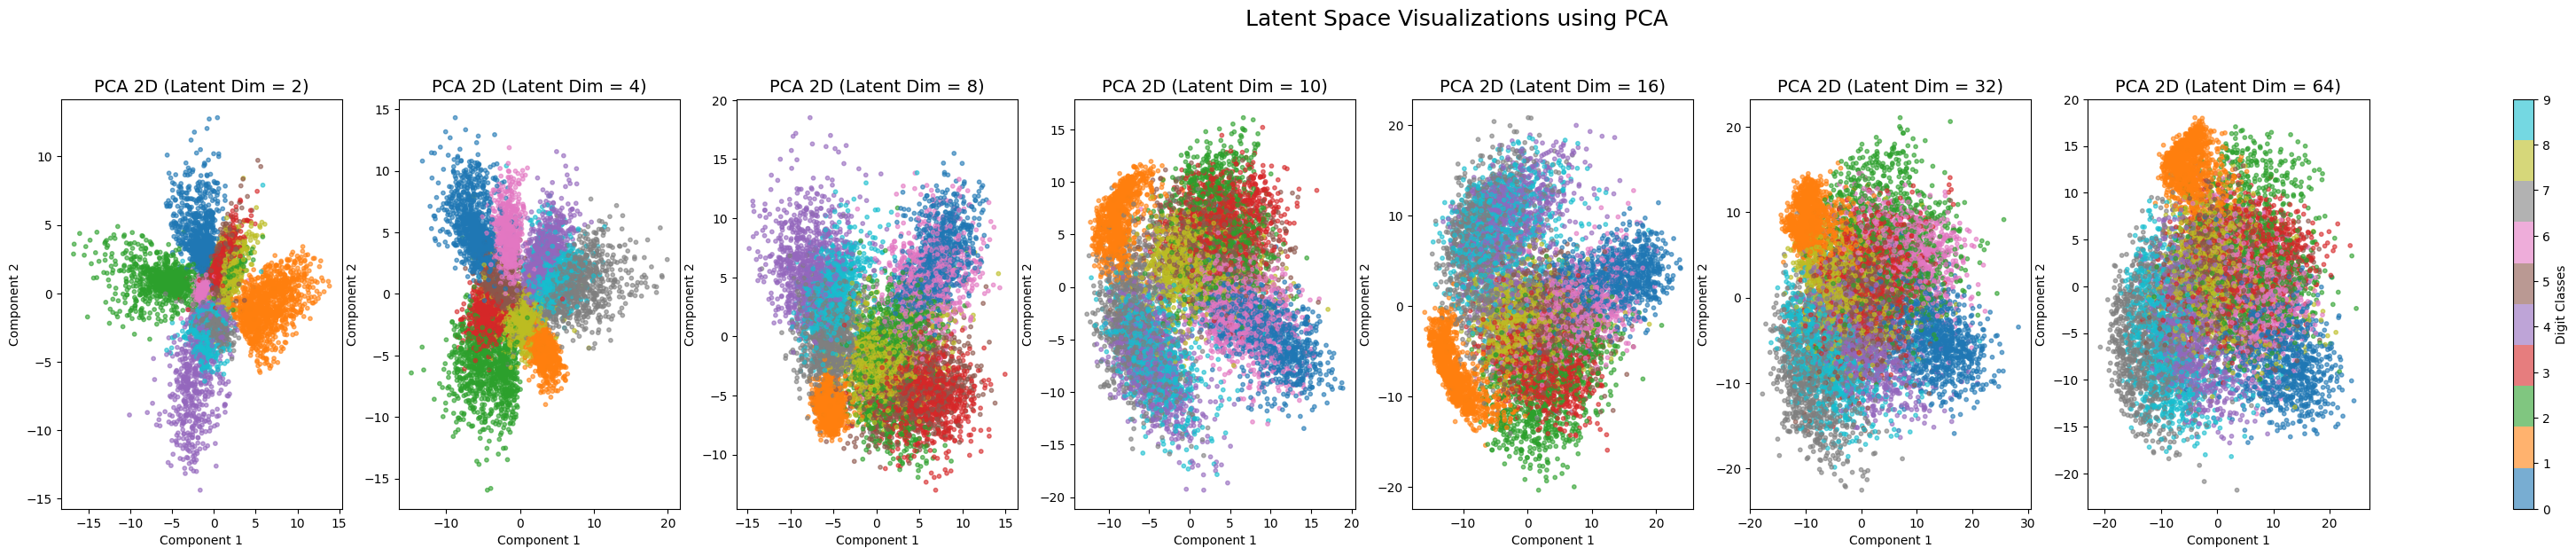



Tüm Modeller İçin t-SNE Çiziliyor (t-SNE PCA'den yavaş olduğu için biraz sürebilir)...


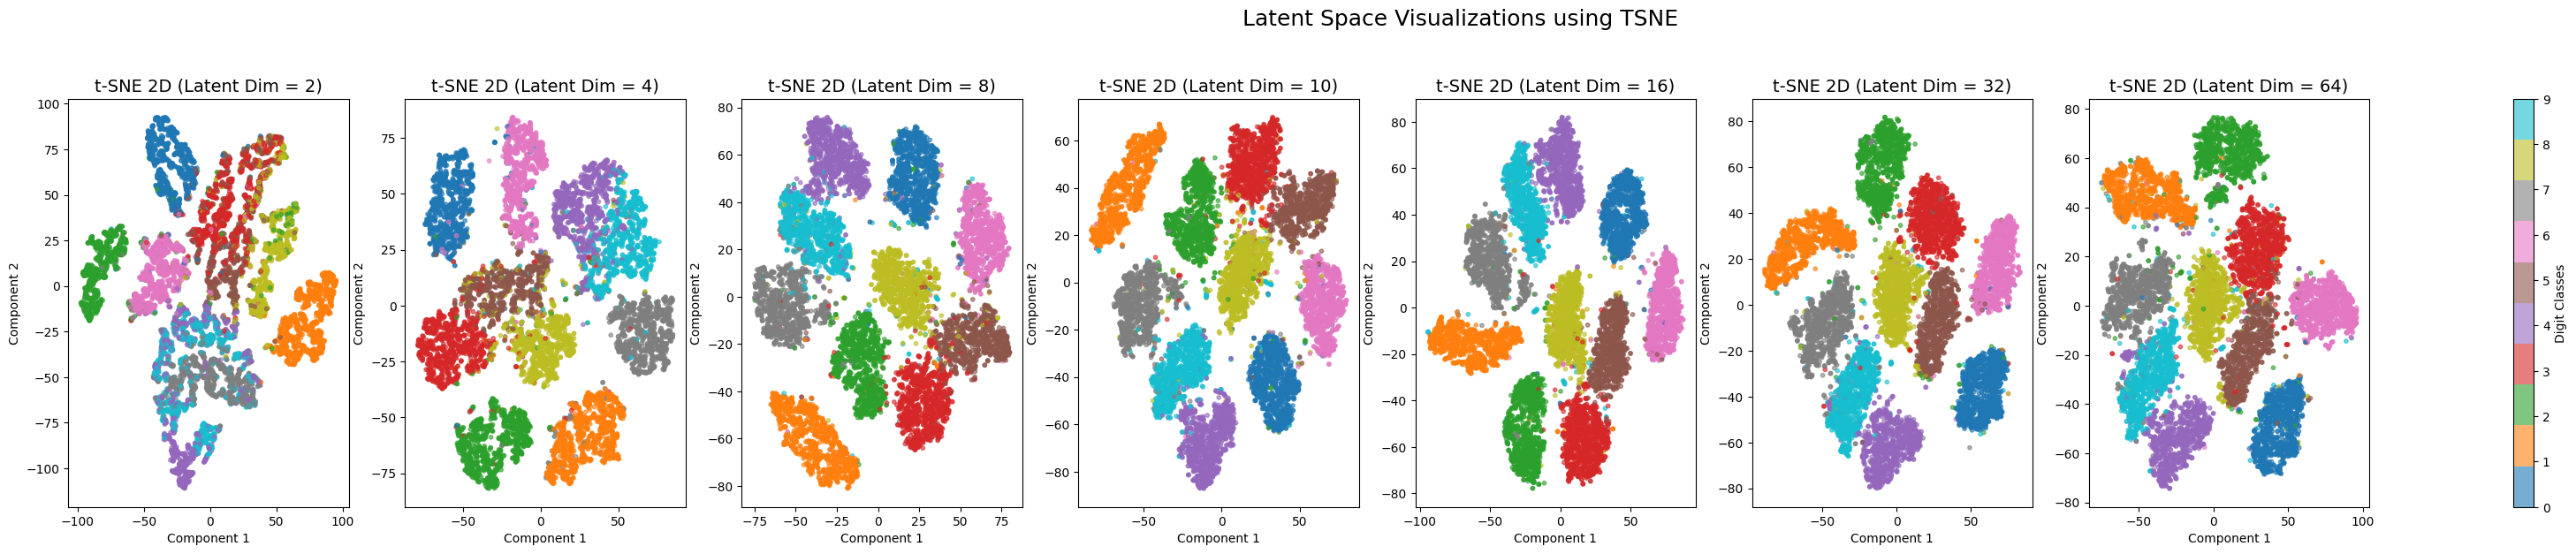

In [10]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_all_latent_spaces(method='pca'):
    # Her bir latent_dim için figürümüzde 1 tane subplot (yan yana) açıyoruz
    fig, axes = plt.subplots(1, len(latent_dims), figsize=(6 * len(latent_dims), 6))
    
    # axes objesi liste değilse (tek boyut varsa) listeye çevirelim hata vermesin
    if len(latent_dims) == 1:
        axes = [axes]
        
    for i, dim in enumerate(latent_dims):
        # latent_data_per_dim sözlüğünde bütün modellerin latent uzayları kayıtlıydı
        current_latent_reps = latent_data_per_dim[dim]
        
        if method.lower() == 'pca':
            reducer = PCA(n_components=2)
            title = f"PCA 2D (Latent Dim = {dim})"
        else:
            # t-SNE için parametreleri veriyoruz
            reducer = TSNE(n_components=2, random_state=42)
            title = f"t-SNE 2D (Latent Dim = {dim})"
            
        reduced_data = reducer.fit_transform(current_latent_reps)
        
        # O boyuta ait scatter grafiğini kendi axes'ine (kutusuna) çiz
        scatter = axes[i].scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
        axes[i].set_title(title, fontsize=14)
        axes[i].set_xlabel('Component 1')
        axes[i].set_ylabel('Component 2')
        
    # Tek bir Colorbar ekleyelim en sağa
    cbar = fig.colorbar(scatter, ax=axes, ticks=range(10), label='Digit Classes')
    
    # Genel Başlık
    fig.suptitle(f"Latent Space Visualizations using {method.upper()}", fontsize=18, y=1.05)
    plt.show()


# 1. BÜTÜN MODELLER İÇİN PCA ÇİZİMİ
print("Tüm Modeller İçin PCA Çiziliyor...")
plot_all_latent_spaces(method='pca')

print("\n" + "="*80 + "\n")

# 2. BÜTÜN MODELLER İÇİN t-SNE ÇİZİMİ
print("Tüm Modeller İçin t-SNE Çiziliyor (t-SNE PCA'den yavaş olduğu için biraz sürebilir)...")
plot_all_latent_spaces(method='tsne')


## 7. Metrics & Clustering (K-Means)
Calculating the final AD, AVC, TD, and PMS.

K-Means ile Farklı Latent Dimension'lar Değerlendiriliyor...

[2 Boyutlu Latent Uzay] Sonuçları:
  PMS (Yanlış Etiketleme Oranı): 49.75%
  AVC (Küme İçi Varyans): 3.5806
  AD (Kümeler Arası Mesafe): 7.9494
  TD (Toplam Mesafe Oranı AVC/AD): 0.4504
--------------------------------------------------
[4 Boyutlu Latent Uzay] Sonuçları:
  PMS (Yanlış Etiketleme Oranı): 31.63%
  AVC (Küme İçi Varyans): 12.9763
  AD (Kümeler Arası Mesafe): 9.3814
  TD (Toplam Mesafe Oranı AVC/AD): 1.3832
--------------------------------------------------
[8 Boyutlu Latent Uzay] Sonuçları:
  PMS (Yanlış Etiketleme Oranı): 18.12%
  AVC (Küme İçi Varyans): 54.0719
  AD (Kümeler Arası Mesafe): 13.4265
  TD (Toplam Mesafe Oranı AVC/AD): 4.0272
--------------------------------------------------
[10 Boyutlu Latent Uzay] Sonuçları:
  PMS (Yanlış Etiketleme Oranı): 16.75%
  AVC (Küme İçi Varyans): 85.7354
  AD (Kümeler Arası Mesafe): 15.7605
  TD (Toplam Mesafe Oranı AVC/AD): 5.4399
-----------------------------------

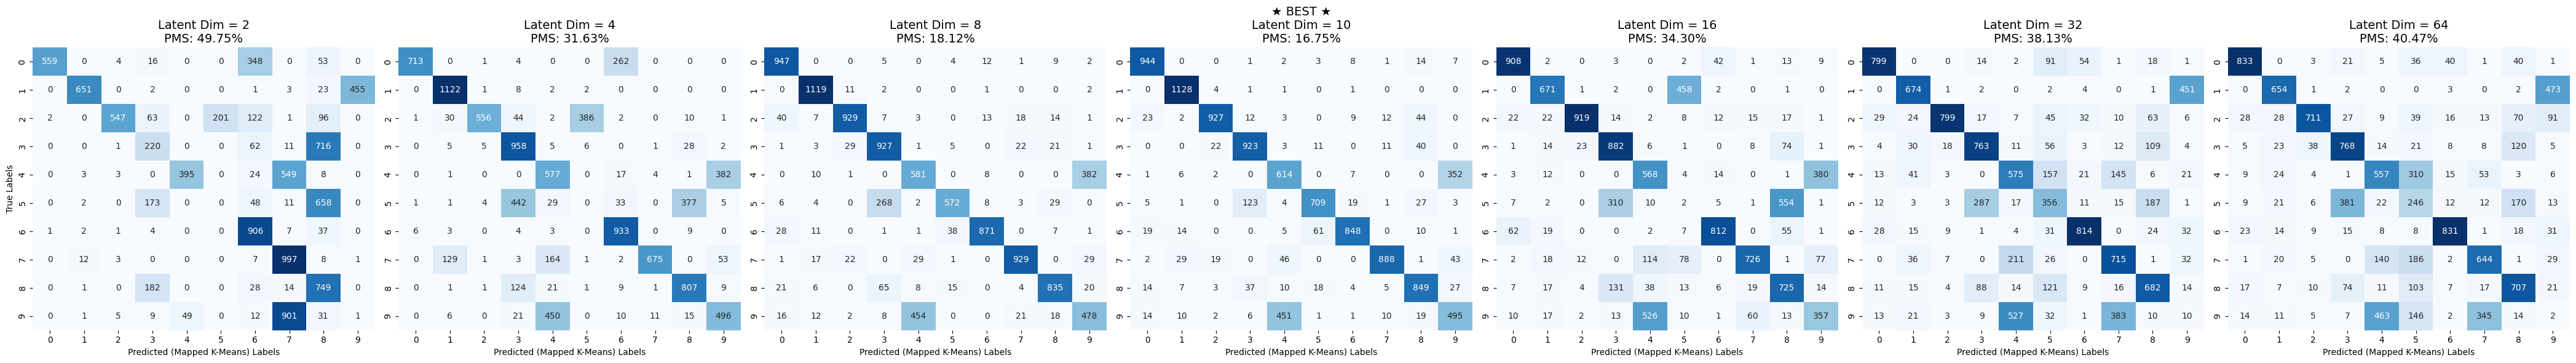

In [11]:
from sklearn.cluster import KMeans
import numpy as np
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def apply_kmeans(latent_representations, n_clusters=10):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    predicted_labels = kmeans.fit_predict(latent_representations)
    return predicted_labels, kmeans.cluster_centers_

def map_clusters(actual_labels, predicted_labels):
    # Map the found clusters (0-9) to the real labels (0-9) using Hungarian Algorithm
    cm = confusion_matrix(actual_labels, predicted_labels)
    row_ind, col_ind = linear_sum_assignment(-cm)
    cluster_to_label = dict(zip(col_ind, row_ind))
    
    mapped = np.copy(predicted_labels)
    for i, p in enumerate(predicted_labels):
        mapped[i] = cluster_to_label.get(p, p)
            
    return mapped

def calculate_metrics(latent_reps, actual_labels, mapped_predictions, cluster_centers):
    # 1. Percentage of Mislabeled Samples (PMS)
    mislabeled = np.sum(actual_labels != mapped_predictions)
    pms = (mislabeled / len(actual_labels)) * 100

    # 2. Average Variance of Clusters (AVC)
    avc = 0
    valid_clusters = 0
    for i in range(10):
        cluster_points = latent_reps[mapped_predictions == i]
        if len(cluster_points) > 0:
            center = np.mean(cluster_points, axis=0)
            var = np.mean(np.sum((cluster_points - center)**2, axis=1))
            avc += var
            valid_clusters += 1
    if valid_clusters > 0:
        avc /= valid_clusters

    # 3. Average Distance between Clusters (AD)
    ad = 0
    num_pairs = 0
    for i in range(10):
        for j in range(i + 1, 10):
            dist = np.sqrt(np.sum((cluster_centers[i] - cluster_centers[j])**2))
            ad += dist
            num_pairs += 1
    if num_pairs > 0:
        ad /= num_pairs

    # 4. Total Distance (TD)
    td = avc / ad if ad > 0 else float('inf')

    return pms, avc, ad, td

print("K-Means ile Farklı Latent Dimension'lar Değerlendiriliyor...\n")

results = []

# Her bir boyut için modeli ve metrikleri test et
for dim in latent_dims:
    current_model = trained_models[dim]
    
    current_latent_reps, current_labels = get_latent_representations_and_images(
        current_model, test_loader, device=device
    )
    
    preds, centers = apply_kmeans(current_latent_reps, n_clusters=10)
    mapped_preds = map_clusters(current_labels, preds)
    
    pms, avc, ad, td = calculate_metrics(current_latent_reps, current_labels, mapped_preds, centers)
    
    results.append({
        'dim': dim,
        'pms': pms,
        'avc': avc,
        'ad': ad,
        'td': td,
        'mapped_preds': mapped_preds,
        'actual_labels': current_labels
    })

    print(f"[{dim} Boyutlu Latent Uzay] Sonuçları:")
    print(f"  PMS (Yanlış Etiketleme Oranı): {pms:.2f}%")
    print(f"  AVC (Küme İçi Varyans): {avc:.4f}")
    print(f"  AD (Kümeler Arası Mesafe): {ad:.4f}")
    print(f"  TD (Toplam Mesafe Oranı AVC/AD): {td:.4f}")
    print("-" * 50)

best_result = min(results, key=lambda x: x['pms'])
print(f"\nEn Düşük Hata Oranına (PMS) Sahip Boyut: {best_result['dim']}\n")

# BÜTÜN MODELLER İÇİN YAN YANA CONFUSION MATRIX ÇİZİMİ
fig, axes = plt.subplots(1, len(latent_dims), figsize=(6 * len(latent_dims), 6))

if len(latent_dims) == 1:
    axes = [axes]

for i, res in enumerate(results):
    cm = confusion_matrix(res['actual_labels'], res['mapped_preds'], labels=range(10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10), ax=axes[i], cbar=False)
    
    # Sadece en iyi modele özel (farklılaşsın diye) başlığa "Best" ekleyelim
    title_prefix = "★ BEST ★\n" if res['dim'] == best_result['dim'] else ""
    axes[i].set_title(f"{title_prefix}Latent Dim = {res['dim']}\nPMS: {res['pms']:.2f}%", fontsize=14)
    axes[i].set_xlabel('Predicted (Mapped K-Means) Labels')
    if i == 0:
        axes[i].set_ylabel('True Labels')
    else:
        axes[i].set_ylabel('')

plt.tight_layout()
plt.show()
